# Risk ratio de dry spells largos en 4 regiones — ALADIN histórico vs futuro

**Pregunta 6 (profesor):** Repetir el ejercicio de risk ratios (estilo Fig. 5 de Martinez-Villalobos & Neelin 2018) comparando un periodo del **clima histórico de ALADIN** con un periodo del **clima futuro de ALADIN**.

Referencia: [10.1029/2018GL078465](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2018GL078465).

> **Analogía con Fig. 5:** eje X = umbral de duración del dry spell (días); eje Y = risk ratio P₂/P₁ con **IC95 por bootstrap por año**.

## Definiciones
- **Fuente:** ALADIN CHP12 (CNRM-ESM2-1, CHP12), grilla curvilínea `y`×`x`.
- **Escenario futuro:** SSP5-8.5 (`ssp585`).
- **Periodos comparables (35 años c/u):** histórico **1980–2014** vs futuro **2040–2074** (misma ventana que Pregunta 9).
- **Día seco (ALADIN):** `pr < 5.285 mm/día` (τ* calibrado en Pregunta 6 para equivaler a 1 mm en CR2MET).
- **Dry spell:** racha consecutiva de días secos; filtro estacional: inicio **marzo–noviembre**.
- **Pool regional:** todas las rachas de píxeles ALADIN dentro de cada región administrativa (Natural Earth).
- **Risk ratio:** P_futuro / P_histórico; significancia si IC95 no cruza RR=1.

## Regiones
Coquimbo, O'Higgins, La Araucanía y Los Lagos.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.prepared import prep
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from IPython.display import display

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['grid.linestyle'] = ':'

# =====================================================================
# CONFIG
# =====================================================================
HIST_START = '1980-01-01'
HIST_END = '2014-12-31'
FUT_START = '2040-01-01'
FUT_END = '2074-12-31'
FUTURE_SCENARIO = 'ssp585'

DRY_THRESHOLD = 5.285  # tau* ALADIN (Pregunta 6)
EVENT_THRESHOLD = 20
BOOTSTRAP_ITER = 1000
RANDOM_SEED = 42
PERIOD_1 = (1980, 2014)
PERIOD_2 = (2040, 2074)
THRESHOLD_SWEEP = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60]
SEASON_MONTH_MIN = 3
SEASON_MONTH_MAX = 11
RR_PLOT_YMAX = 4.0

REGION_SPECS = {
    'Coquimbo': {'query': 'Coquimbo', 'color': 'firebrick'},
    "O'Higgins": {'query': 'higgins', 'color': 'darkorange'},
    'La Araucanía': {'query': 'araucan', 'color': 'forestgreen'},
    'Los Lagos': {'query': 'los lagos', 'color': 'steelblue'},
}


def normalize_text(text):
    text = unicodedata.normalize('NFKD', str(text).lower())
    return ''.join(ch for ch in text if not unicodedata.combining(ch))


def get_region_record(query, chile_records):
    query_norm = normalize_text(query)
    for record in chile_records:
        name_norm = normalize_text(record.attributes.get('name', ''))
        if query_norm in name_norm:
            return record
    raise ValueError(f'No se encontro region chilena para: {query}')


def build_region_mask(lat2d, lon2d, polygon):
    prepg = prep(polygon)
    return np.fromiter(
        (
            prepg.contains(Point(float(lon2d[j, i]), float(lat2d[j, i])))
            or polygon.touches(Point(float(lon2d[j, i]), float(lat2d[j, i])))
            for j in range(lat2d.shape[0])
            for i in range(lat2d.shape[1])
        ),
        dtype=bool,
        count=lat2d.size,
    ).reshape(lat2d.shape)


def time_to_year(t):
    if hasattr(t, 'year'):
        return int(t.year)
    return int(pd.Timestamp(t).year)


def time_to_month(t):
    if hasattr(t, 'month'):
        return int(t.month)
    return int(pd.Timestamp(t).month)


def open_aladin_period(start, end, scenario=None):
    if scenario is None:
        files = sorted(Path('pr1').glob('pr_CHP12_*_historical_*.nc'))
    else:
        files = sorted(Path('pr1').glob(f'pr_CHP12_*_{scenario}_*.nc'))
    ds = xr.open_mfdataset([str(p) for p in files], use_cftime=True, chunks={'time': 365})
    return ds['pr'].sel(time=slice(start, end)) * 86400.0


def extract_dry_spells_aladin(pr_da, region_mask, dry_threshold,
                              season_month_min=SEASON_MONTH_MIN, season_month_max=SEASON_MONTH_MAX):
    is_dry = (pr_da < dry_threshold).where(region_mask)
    stacked = is_dry.stack(cell=('y', 'x')).transpose('time', 'cell').compute()
    times = stacked['time'].values
    vals = stacked.values
    records = []
    for idx in range(vals.shape[1]):
        col = vals[:, idx]
        if not np.any(col):
            continue
        x = np.asarray(col, dtype=bool)
        padded = np.r_[False, x, False]
        dx = np.diff(padded.astype(np.int8))
        starts, ends = np.where(dx == 1)[0], np.where(dx == -1)[0]
        for s, e in zip(starts, ends):
            duration = int(e - s)
            if duration <= 0:
                continue
            start_month = time_to_month(times[s])
            if start_month < season_month_min or start_month > season_month_max:
                continue
            records.append({
                'start_year': time_to_year(times[s]),
                'start_month': start_month,
                'duration': duration,
            })
    return pd.DataFrame(records)


def event_probability(spell_df, start_year, end_year, min_duration):
    subset = spell_df[
        (spell_df['start_year'] >= start_year) & (spell_df['start_year'] <= end_year)
    ]
    total_spells = int(len(subset))
    event_spells = int((subset['duration'] >= min_duration).sum())
    probability = np.nan if total_spells == 0 else event_spells / total_spells
    return subset, probability, event_spells, total_spells


def risk_ratio(prob_period_2, prob_period_1):
    if prob_period_1 == 0 or not np.isfinite(prob_period_1):
        return np.nan
    return prob_period_2 / prob_period_1


def bootstrap_rr_by_year(spell_df, years_1, years_2, min_duration, n_iter=BOOTSTRAP_ITER, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    grouped = {
        year: spell_df.loc[spell_df['start_year'] == year, 'duration'].to_numpy()
        for year in sorted(spell_df['start_year'].unique())
    }
    years_1 = np.array(list(years_1))
    years_2 = np.array(list(years_2))
    rr_values = []
    for _ in range(n_iter):
        draw_1 = rng.choice(years_1, size=len(years_1), replace=True)
        draw_2 = rng.choice(years_2, size=len(years_2), replace=True)
        sample_1 = np.concatenate([grouped[y] for y in draw_1 if y in grouped and grouped[y].size > 0])
        sample_2 = np.concatenate([grouped[y] for y in draw_2 if y in grouped and grouped[y].size > 0])
        if sample_1.size == 0 or sample_2.size == 0:
            continue
        p1 = np.mean(sample_1 >= min_duration)
        p2 = np.mean(sample_2 >= min_duration)
        if p1 > 0:
            rr_values.append(p2 / p1)
    return np.array(rr_values)


def bootstrap_rr_curve(spell_df, years_1, years_2, thresholds, n_iter=BOOTSTRAP_ITER, seed=RANDOM_SEED):
    rows = []
    for thr in thresholds:
        _, p1, _, _ = event_probability(spell_df, PERIOD_1[0], PERIOD_1[1], thr)
        _, p2, _, _ = event_probability(spell_df, PERIOD_2[0], PERIOD_2[1], thr)
        rr_boot = bootstrap_rr_by_year(spell_df, years_1, years_2, thr, n_iter=n_iter, seed=seed)
        if rr_boot.size == 0:
            ci_low = ci_high = ci_med = np.nan
        else:
            ci_low, ci_high = np.percentile(rr_boot, [2.5, 97.5])
            ci_med = np.median(rr_boot)
        rr_obs = risk_ratio(p2, p1)
        rows.append({
            'Umbral (dias)': thr,
            'RR': rr_obs,
            'RR bootstrap mediano': ci_med,
            'IC95 inferior': ci_low,
            'IC95 superior': ci_high,
            'Significativo aumento': np.isfinite(ci_low) and ci_low > 1.0,
            'Significativo disminucion': np.isfinite(ci_high) and ci_high < 1.0,
            'P1 (%)': p1 * 100 if np.isfinite(p1) else np.nan,
            'P2 (%)': p2 * 100 if np.isfinite(p2) else np.nan,
        })
    return pd.DataFrame(rows)


def load_region_spell_data(pr_hist, pr_fut, lat2d, lon2d, y_coord, x_coord, record):
    geom = record.geometry
    region_name = record.attributes.get('name', 'region')
    mask = build_region_mask(lat2d, lon2d, geom)
    mask_da = xr.DataArray(
        mask,
        coords={'y': y_coord, 'x': x_coord, 'lat': (['y', 'x'], lat2d), 'lon': (['y', 'x'], lon2d)},
        dims=('y', 'x'),
    )
    spell_hist = extract_dry_spells_aladin(pr_hist, mask_da, DRY_THRESHOLD)
    spell_fut = extract_dry_spells_aladin(pr_fut, mask_da, DRY_THRESHOLD)
    spell_df = pd.concat([spell_hist, spell_fut], ignore_index=True)
    minx, miny, maxx, maxy = geom.bounds
    return {
        'name': region_name,
        'geom': geom,
        'bounds': (minx, miny, maxx, maxy),
        'mask': mask,
        'mask_da': mask_da,
        'spell_df': spell_df,
        'pixels': int(mask.sum()),
    }

print('1/4: Cargando ALADIN historico y futuro...')
pr_hist = open_aladin_period(HIST_START, HIST_END)
pr_fut = open_aladin_period(FUT_START, FUT_END, scenario=FUTURE_SCENARIO)
lat2d = pr_hist['lat'].values
lon2d = pr_hist['lon'].values

shape_path = shpreader.natural_earth(
    resolution='10m', category='cultural', name='admin_1_states_provinces'
)
reader = shpreader.Reader(shape_path)
CHILE_REGIONS = [r for r in reader.records() if r.attributes.get('admin') == 'Chile']

n_y1 = PERIOD_1[1] - PERIOD_1[0] + 1
n_y2 = PERIOD_2[1] - PERIOD_2[0] + 1
print(f'Periodo hist: {PERIOD_1[0]}-{PERIOD_1[1]} ({n_y1} anos) | futuro: {PERIOD_2[0]}-{PERIOD_2[1]} ({n_y2} anos, {FUTURE_SCENARIO})')
print(f'Dia seco ALADIN: pr < {DRY_THRESHOLD} mm/dia | Mar-Nov')


1/4: Cargando ALADIN historico y futuro...
Periodo hist: 1980-2014 (35 anos) | futuro: 2040-2074 (35 anos, ssp585)
Dia seco ALADIN: pr < 5.285 mm/dia | Mar-Nov


2/4: Extrayendo dry spells por region...
  Coquimbo         | Coquimbo               | pixeles:  239 | spells: 311,788
  O'Higgins        | Libertador General Bernardo O'Higgins | pixeles:  110 | spells: 229,994
  La Araucanía     | La Araucanía           | pixeles:  223 | spells: 623,736
  Los Lagos        | Los Lagos              | pixeles:  324 | spells: 922,437


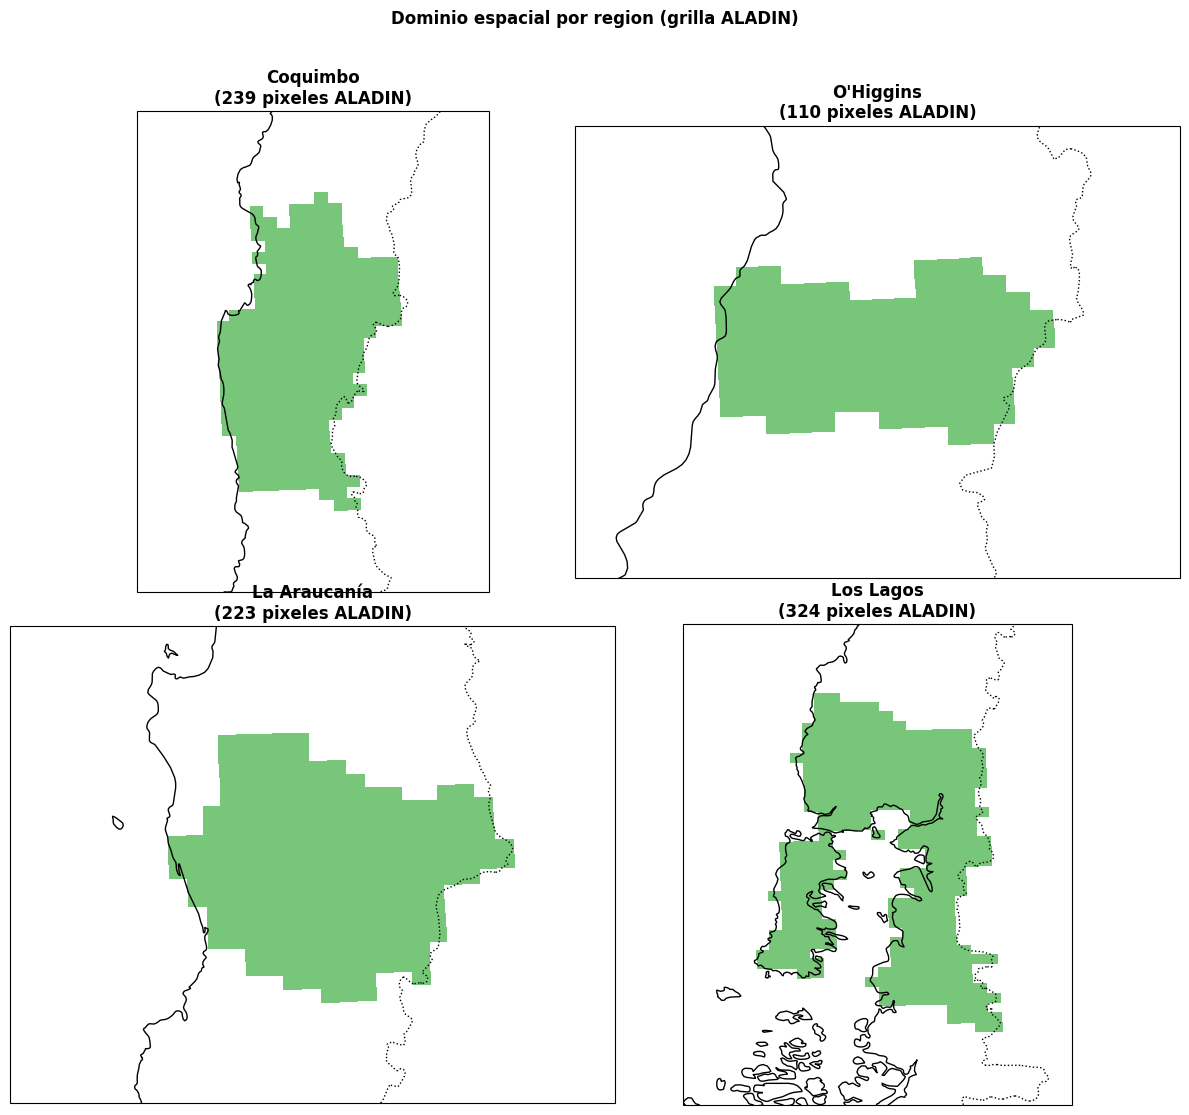

In [2]:
# =====================================================================
# EXTRACCION DE DRY SPELLS EN LAS 4 REGIONES (ALADIN)
# =====================================================================
print('2/4: Extrayendo dry spells por region...')

REGION_DATA = {}
for label, spec in REGION_SPECS.items():
    record = get_region_record(spec['query'], CHILE_REGIONS)
    data = load_region_spell_data(
        pr_hist, pr_fut, lat2d, lon2d, pr_hist['y'], pr_hist['x'], record
    )
    REGION_DATA[label] = data
    print(
        f"  {label:16s} | {data['name']:22s} | "
        f"pixeles: {data['pixels']:4d} | spells: {len(data['spell_df']):,}"
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 11), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.ravel()

for ax, (label, spec) in zip(axes, REGION_SPECS.items()):
    data = REGION_DATA[label]
    minx, miny, maxx, maxy = data['bounds']
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([minx - 0.8, maxx + 0.8, miny - 0.8, maxy + 0.8])

    plot_da = data['mask_da'].astype(float).where(data['mask_da'])
    plot_da.plot.pcolormesh(
        ax=ax, x='lon', y='lat', transform=ccrs.PlateCarree(),
        cmap='YlGn', add_colorbar=False,
    )
    ax.set_title(f"{label}\n({data['pixels']} pixeles ALADIN)", fontweight='bold')

fig.suptitle('Dominio espacial por region (grilla ALADIN)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [3]:
# =====================================================================
# RISK RATIO A 20 DIAS + BOOTSTRAP (4 REGIONES)
# =====================================================================
print(f'3/4: Risk ratio para dry spells >= {EVENT_THRESHOLD} dias...')

years_1 = range(PERIOD_1[0], PERIOD_1[1] + 1)
years_2 = range(PERIOD_2[0], PERIOD_2[1] + 1)

summary_rows = []
rr_rows = []

for label in REGION_SPECS:
    spell_df = REGION_DATA[label]['spell_df']

    _, prob_1, hits_1, total_1 = event_probability(spell_df, PERIOD_1[0], PERIOD_1[1], EVENT_THRESHOLD)
    _, prob_2, hits_2, total_2 = event_probability(spell_df, PERIOD_2[0], PERIOD_2[1], EVENT_THRESHOLD)
    rr_obs = risk_ratio(prob_2, prob_1)

    rr_boot = bootstrap_rr_by_year(spell_df, years_1, years_2, EVENT_THRESHOLD)
    if rr_boot.size > 0:
        ci_low, ci_med, ci_high = np.percentile(rr_boot, [2.5, 50, 97.5])
    else:
        ci_low = ci_med = ci_high = np.nan

    summary_rows.extend([
        {
            'Region': label,
            'Periodo': f'{PERIOD_1[0]}-{PERIOD_1[1]}',
            'Dry spells totales': total_1,
            f'Spells >= {EVENT_THRESHOLD} d': hits_1,
            'Probabilidad (%)': prob_1 * 100 if np.isfinite(prob_1) else np.nan,
        },
        {
            'Region': label,
            'Periodo': f'{PERIOD_2[0]}-{PERIOD_2[1]}',
            'Dry spells totales': total_2,
            f'Spells >= {EVENT_THRESHOLD} d': hits_2,
            'Probabilidad (%)': prob_2 * 100 if np.isfinite(prob_2) else np.nan,
        },
    ])

    rr_rows.append({
        'Region': label,
        'Pixeles': REGION_DATA[label]['pixels'],
        'RR observado': rr_obs,
        'RR bootstrap mediano': ci_med,
        'IC95 inferior': ci_low,
        'IC95 superior': ci_high,
        'Cruza RR=1': (ci_low <= 1 <= ci_high) if np.all(np.isfinite([ci_low, ci_high])) else np.nan,
    })

summary_table = pd.DataFrame(summary_rows)
rr_table = pd.DataFrame(rr_rows)

display(summary_table.round(3))
display(rr_table.round(3))


3/4: Risk ratio para dry spells >= 20 dias...


,Region,Periodo,Dry spells totales,Spells >= 20 d,Probabilidad (%)
0,Coquimbo,1980-2014,165889,25522,15.385
1,Coquimbo,2040-2074,145899,28571,19.583
2,O'Higgins,1980-2014,121591,7015,5.769
3,O'Higgins,2040-2074,108403,8159,7.527
4,La Araucanía,1980-2014,322205,2397,0.744
5,La Araucanía,2040-2074,301531,4118,1.366
6,Los Lagos,1980-2014,471361,601,0.128
7,Los Lagos,2040-2074,451076,1291,0.286


,Region,Pixeles,RR observado,RR bootstrap mediano,IC95 inferior,IC95 superior,Cruza RR=1
0,Coquimbo,239,1.273,1.272,1.094,1.477,False
1,O'Higgins,110,1.305,1.305,1.041,1.625,False
2,La Araucanía,223,1.836,1.870,1.158,3.118,False
3,Los Lagos,324,2.245,2.347,0.913,9.065,True


4/4: Risk ratio vs umbral con bootstrap (4 regiones)...


,Umbral (dias),RR,RR bootstrap mediano,IC95 inferior,IC95 superior,Significativo aumento,Significativo disminucion,P1 (%),P2 (%),Region
0,20,1.273,1.272,1.094,1.477,True,False,15.385,19.583,Coquimbo
1,20,1.305,1.305,1.041,1.625,True,False,5.769,7.527,O'Higgins
2,20,1.836,1.870,1.158,3.118,True,False,0.744,1.366,La Araucanía
3,20,2.245,2.347,0.913,9.065,False,False,0.128,0.286,Los Lagos


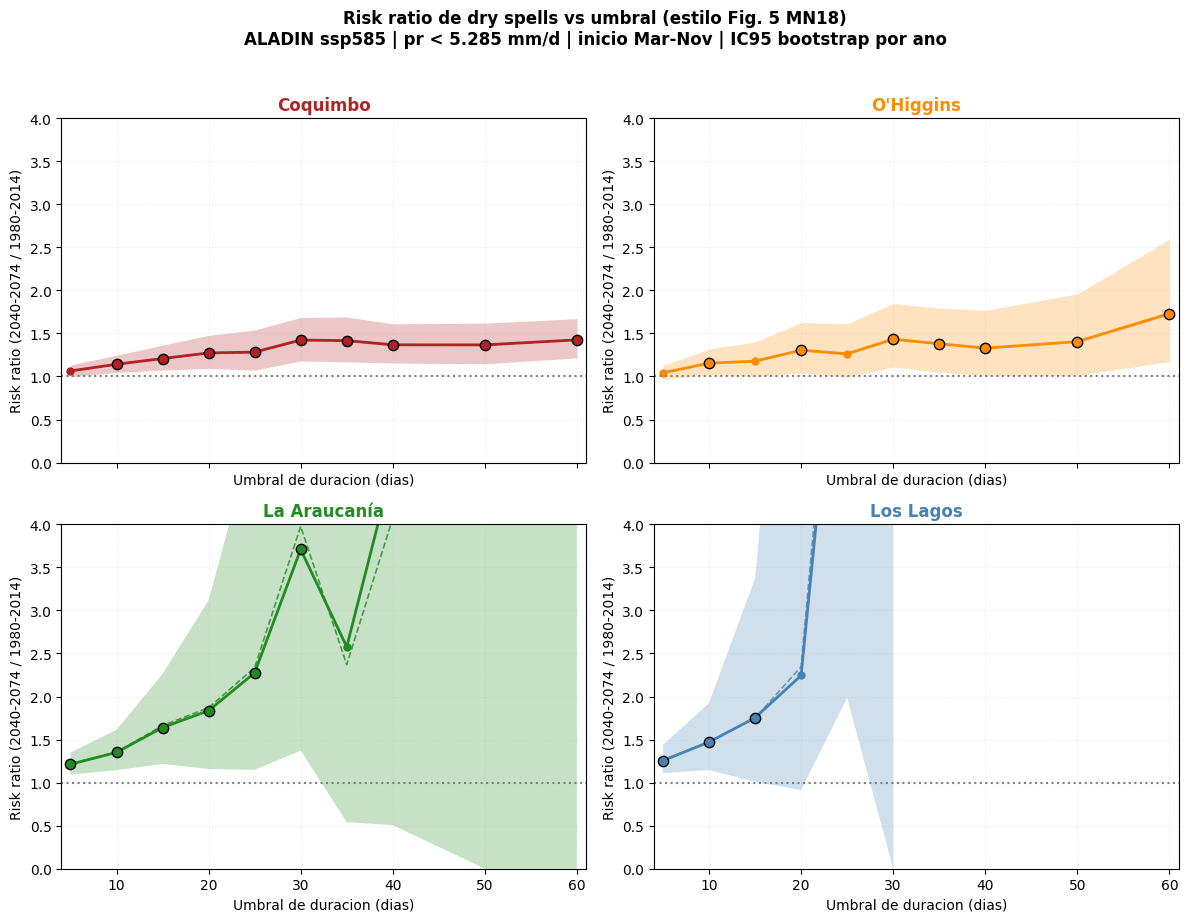

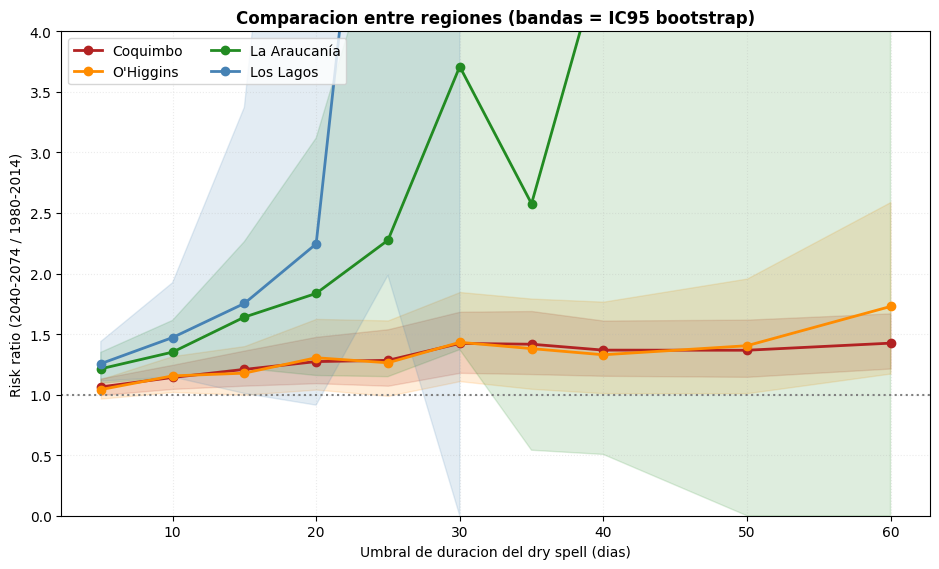

,Region,RR @ 20d,IC95 inf,IC95 sup,Significancia
0,Coquimbo,1.273,1.094,1.477,aumento
1,O'Higgins,1.305,1.041,1.625,aumento
2,La Araucanía,1.836,1.158,3.118,aumento
3,Los Lagos,2.245,0.913,9.065,no


Lectura:
  - RR > 1: mayor probabilidad de dry spells largos en el futuro ALADIN (SSP5-8.5).
  - Puntos rellenos: IC95 completamente por encima de RR=1 (aumento significativo).
  - Los Lagos: probabilidades base muy bajas -> IC95 amplio; interpretar con cautela.


In [4]:
# =====================================================================
# FIGURA ESTILO FIG. 5 (MN18): RR VS UMBRAL + IC95 BOOTSTRAP
# =====================================================================
print('4/4: Risk ratio vs umbral con bootstrap (4 regiones)...')

years_1 = range(PERIOD_1[0], PERIOD_1[1] + 1)
years_2 = range(PERIOD_2[0], PERIOD_2[1] + 1)

threshold_by_region = {}
for label in REGION_SPECS:
    spell_df = REGION_DATA[label]['spell_df']
    threshold_by_region[label] = bootstrap_rr_curve(
        spell_df, years_1, years_2, THRESHOLD_SWEEP, n_iter=BOOTSTRAP_ITER, seed=RANDOM_SEED,
    )

table_20 = pd.concat(
    [threshold_by_region[label].loc[threshold_by_region[label]['Umbral (dias)'] == EVENT_THRESHOLD]
     .assign(Region=label)
     for label in REGION_SPECS],
    ignore_index=True,
)
display(table_20.round(3))

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
axes = axes.ravel()

period_label = f'{PERIOD_2[0]}-{PERIOD_2[1]} / {PERIOD_1[0]}-{PERIOD_1[1]}'

for ax, (label, spec) in zip(axes, REGION_SPECS.items()):
    tdf = threshold_by_region[label]
    color = spec['color']
    x = tdf['Umbral (dias)'].to_numpy()
    rr = tdf['RR'].to_numpy()
    lo = tdf['IC95 inferior'].to_numpy()
    hi = tdf['IC95 superior'].to_numpy()

    valid = np.isfinite(rr) & np.isfinite(lo) & np.isfinite(hi)
    if valid.any():
        ax.fill_between(x[valid], lo[valid], hi[valid], color=color, alpha=0.25, linewidth=0)
        ax.plot(x[valid], rr[valid], color=color, marker='o', linewidth=2, markersize=5, label='RR')
        ax.plot(x[valid], tdf.loc[valid, 'RR bootstrap mediano'], color=color, linestyle='--', linewidth=1.2, alpha=0.8)

        sig_up = tdf.loc[valid, 'Significativo aumento'].to_numpy()
        sig_down = tdf.loc[valid, 'Significativo disminucion'].to_numpy()
        if sig_up.any():
            ax.scatter(x[valid][sig_up], rr[valid][sig_up], s=55, facecolors=color, edgecolors='k', zorder=5)
        if sig_down.any():
            ax.scatter(x[valid][sig_down], rr[valid][sig_down], s=55, facecolors='white', edgecolors=color, linewidth=1.5, zorder=5)

    ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(label, fontweight='bold', color=color)
    ax.set_xlabel('Umbral de duracion (dias)')
    ax.set_ylabel(f'Risk ratio ({period_label})')
    ax.set_xlim(THRESHOLD_SWEEP[0] - 1, THRESHOLD_SWEEP[-1] + 1)
    ax.set_ylim(0, RR_PLOT_YMAX)

fig.suptitle(
    'Risk ratio de dry spells vs umbral (estilo Fig. 5 MN18)\n'
    f'ALADIN {FUTURE_SCENARIO} | pr < {DRY_THRESHOLD} mm/d | inicio Mar-Nov | IC95 bootstrap por ano',
    fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 5.8))
for label, spec in REGION_SPECS.items():
    tdf = threshold_by_region[label]
    valid = tdf['RR'].notna() & tdf['IC95 inferior'].notna() & tdf['IC95 superior'].notna()
    x = tdf.loc[valid, 'Umbral (dias)']
    ax.fill_between(x, tdf.loc[valid, 'IC95 inferior'], tdf.loc[valid, 'IC95 superior'], color=spec['color'], alpha=0.15)
    ax.plot(x, tdf.loc[valid, 'RR'], color=spec['color'], marker='o', linewidth=2, label=label)

ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.5)
ax.set_xlabel('Umbral de duracion del dry spell (dias)')
ax.set_ylabel(f'Risk ratio ({period_label})')
ax.set_title('Comparacion entre regiones (bandas = IC95 bootstrap)', fontweight='bold')
ax.set_ylim(0, RR_PLOT_YMAX)
ax.legend(loc='upper left', frameon=True, ncol=2)
plt.tight_layout()
plt.show()

sig_table = pd.DataFrame([
    {
        'Region': label,
        'RR @ 20d': threshold_by_region[label].loc[threshold_by_region[label]['Umbral (dias)'] == EVENT_THRESHOLD, 'RR'].iloc[0],
        'IC95 inf': threshold_by_region[label].loc[threshold_by_region[label]['Umbral (dias)'] == EVENT_THRESHOLD, 'IC95 inferior'].iloc[0],
        'IC95 sup': threshold_by_region[label].loc[threshold_by_region[label]['Umbral (dias)'] == EVENT_THRESHOLD, 'IC95 superior'].iloc[0],
        'Significancia': (
            'aumento' if threshold_by_region[label].loc[threshold_by_region[label]['Umbral (dias)'] == EVENT_THRESHOLD, 'Significativo aumento'].iloc[0]
            else ('disminucion' if threshold_by_region[label].loc[threshold_by_region[label]['Umbral (dias)'] == EVENT_THRESHOLD, 'Significativo disminucion'].iloc[0] else 'no')
        ),
    }
    for label in REGION_SPECS
])
display(sig_table.round(3))

print('Lectura:')
print('  - RR > 1: mayor probabilidad de dry spells largos en el futuro ALADIN (SSP5-8.5).')
print('  - Puntos rellenos: IC95 completamente por encima de RR=1 (aumento significativo).')
print('  - Los Lagos: probabilidades base muy bajas -> IC95 amplio; interpretar con cautela.')


## Conclusiones (ALADIN hist vs SSP5-8.5 2040–2074)

1. **Señal consistente de aumento** en la probabilidad de dry spells largos bajo cambio climático en las 4 regiones: RR > 1 en prácticamente todos los umbrales ≥10 días.
2. **Coquimbo y O'Higgins (zonas secas):** RR ≈ 1.27–1.30 a 20 días, **significativo** (IC95 inferior > 1). La probabilidad sube ~4 pp (Coquimbo: 15.4% → 19.6%) y ~1.8 pp (O'Higgins: 5.8% → 7.5%).
3. **La Araucanía:** el cambio es más fuerte (RR ≈ 1.84 a 20 d, IC95: 1.16–3.12, significativo). A umbrales ≥25 días el RR supera 2 con significancia — señal de **cola pesada** más seca en el futuro.
4. **Los Lagos (zona muy húmeda):** RR observado ≈ 2.2 a 20 días pero **IC95 muy amplio** (0.91–9.1) por probabilidades base muy bajas (<0.13%); a 25 días sí hay aumento significativo (RR ≈ 7.6). Hay que interpretar con cautela por escasez de eventos extremos.
5. **Comparación con CR2MET (1980–2000 vs 2001–2021):** en observacional el cambio reciente era débil/no significativo (RR ~1.05–1.17, IC95 cruzando 1). ALADIN proyecta un **cambio futuro más claro y sistemático** hacia más dry spells largos, coherente con la tendencia de aridización en el sur-centro de Chile.
6. **Metodología:** τ* = 5.285 mm evita subestimar días secos por el sesgo húmedo de ALADIN; ventanas de 35 años equilibran histórico disponible (hasta 2014) con proyección futura.